In [2]:
import matplotlib.pyplot as plt
from ultralytics import YOLO
import cv2
from glob import glob

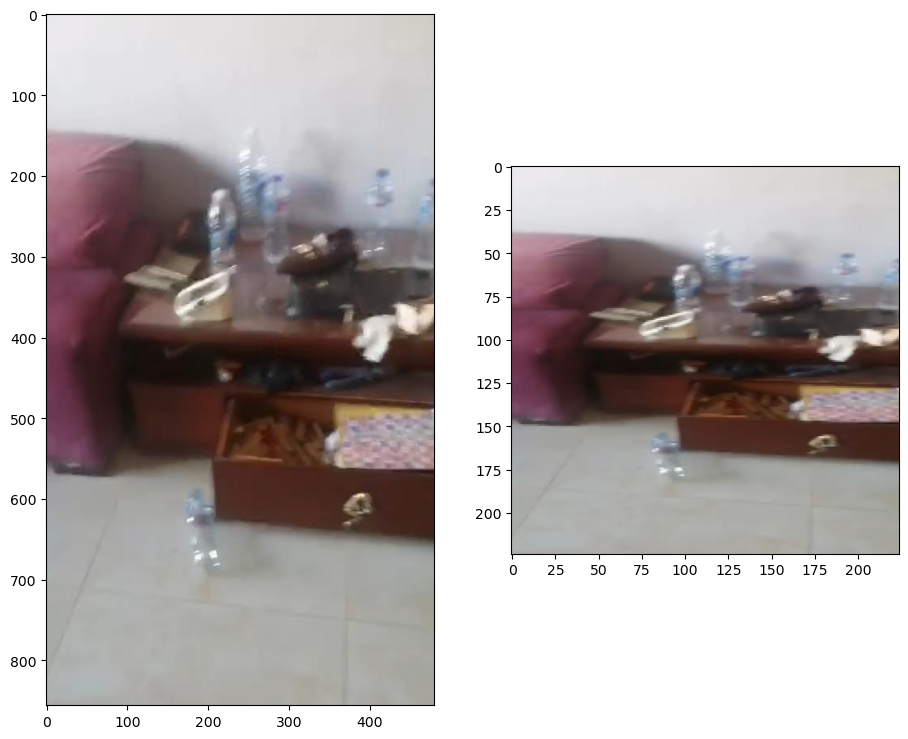

In [3]:
sample_img = cv2.imread(glob("./data/train/images/*.jpg")[60])
assert sample_img is not None, "Sample Image not found"

sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
resized = cv2.resize(sample_img, (224, 224))

plt.figure(figsize=(11, 10))
plt.subplot(121)
plt.imshow(sample_img)

plt.subplot(122)
plt.imshow(resized)

In [5]:
model = YOLO("yolo26n.pt") 

results = model.train(
    data="./data/data.yaml",
    epochs=200,
    imgsz=320,
    
    # native Ultralytics augmentations
    degrees=90,      # random rotation in [-90, +90]
    shear=9,         # random shear in [-9, +9]
    fliplr=0.5,      # horizontal flip probability
    flipud=0.5,      # vertical flip probability

    # HSV uses fractions, not degrees
    hsv_h=21 / 360,  # ±21 degrees hue shift
    hsv_s=0.30,      # ±30% saturation shift
    hsv_v=0.15,      # ±15% brightness shift

    # optional regular training settings
    mosaic=1.0,
    mixup=0.0,
    close_mosaic=10,
)

New https://pypi.org/project/ultralytics/8.4.59 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.56  Python-3.11.14 torch-2.9.1+cpu CPU (11th Gen Intel Core i7-1165G7 @ 2.80GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./data/data.yaml, degrees=90, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.058333333333333334, hsv_s=0.3, hsv_v=0.15, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_sc

KeyboardInterrupt: 

In [9]:
best_model = YOLO("C:/Users/zeyad/Master/1_Projects/1_Active/MegaTroll/ai_training/bottle_ds_training/runs/detect/train-9/weights/best.pt")
best_model.export(format="ncnn")

Ultralytics 8.4.56  Python-3.11.14 torch-2.9.1+cpu CPU (11th Gen Intel Core i7-1165G7 @ 2.80GHz)
WARNING NCNN export does not support end2end models, disabling end2end branch.
YOLO26n summary (fused): 146 layers, 2,494,694 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from 'C:\Users\zeyad\Master\1_Projects\1_Active\MegaTroll\ai_training\bottle_ds_training\runs\detect\train-9\weights\best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 5, 2100) (19.8 MB)

NCNN: starting export with NCNN 1.0.20260114 and PNNX 20260409...
NCNN: export success  7.4s, saved as 'C:\Users\zeyad\Master\1_Projects\1_Active\MegaTroll\ai_training\bottle_ds_training\runs\detect\train-9\weights\best_ncnn_model' (9.2 MB)

Export complete (7.8s)
Results saved to C:\Users\zeyad\Master\1_Projects\1_Active\MegaTroll\ai_training\bottle_ds_training\runs\detect\train-9\weights\best_ncnn_model
Predict:         yolo predict task=detect model=C:\Users\zeyad\Master\1_Projects\1_Active\MegaTroll\ai_t

'C:\\Users\\zeyad\\Master\\1_Projects\\1_Active\\MegaTroll\\ai_training\\bottle_ds_training\\runs\\detect\\train-9\\weights\\best_ncnn_model'